# Chapter 5. Decomposition of Symmetric Spaces

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter V, printed pages 229-251 (approximately PDF pages 256-278).

**Chapter Goal.** Learn how symmetric spaces split into Euclidean, compact, and noncompact factors, how compact/noncompact duality flips curvature, and why rank is the dimension of a largest flat totally geodesic piece.

**Translation guide.**

- The input is an effective orthogonal symmetric Lie algebra `(l, s)` with eigenspace split `l = u + e`.
- The Killing form on `e` separates the algebra into three ideals: zero directions give the Euclidean part, negative directions give the compact type, and positive directions give the noncompact type.
- Duality keeps `u` and replaces `e` by `i e`; this turns compact models into noncompact models and reverses the curvature sign.
- Sectional curvature is controlled by `[X,Y]`: flat sections are exactly abelian subspaces of `e`.
- For semisimple symmetric spaces, the connected isometry group is already the transvection group, and the isotropy algebra is spanned by curvature endomorphisms.
- Rank is the maximal dimension of an abelian subspace of `e`; geometrically, it is the dimension of a largest flat, totally geodesic submanifold.


## Visual Storyboard and Library Routing

| Source block | Representation | Library route | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| Section 1: orthogonal symmetric Lie algebras | three model brackets: Euclidean, compact, noncompact | SymPy + Matplotlib | how `[e,e]` and Killing signs distinguish the types | bracket and Killing-sign checks |
| Theorem 1.1 decomposition | block diagram of `l0 + l- + l+` | NetworkX/Matplotlib | direct-sum factors and their curvature roles | graph contains all factor paths |
| Section 2: duality | compact `so(3)/so(2)` versus noncompact `sl(2,R)/so(2)` | SymPy + Matplotlib | replacing `e` by `i e` flips the bracket sign | exact dual bracket checks |
| Section 3: sectional curvature | sign bar chart from `B([X,Y],[X,Y])` | SymPy + Matplotlib | compact >= 0, noncompact <= 0, Euclidean = 0 | exact sign checks |
| Section 4: semisimple isometry groups | `[e,e] = u` curvature-span table | SymPy + CSV | why the isotropy algebra is generated by curvature | span checks |
| Proposition 4.2: product decomposition | product factor diagram | NetworkX/Matplotlib | simply connected `M = M0 x M- x M+` | component and sign checks |
| Sections 5-6: notation and rank | rank-one and rank-two maximal-flat models | Matplotlib + SymPy | rank as maximal abelian dimension | commutator checks |
| Theorem 6.7: `KAK`/complex distance | `SL(3,R)/SO(3)` diagonal chamber | Matplotlib + NumPy | symmetric trace-free matrices move by isotropy into a maximal abelian diagonal flat | diagonalization residual and chamber checks |

Matplotlib is the durable renderer for static structure diagrams; NetworkX is used only for proof/factor dependency graphs; SymPy supplies exact bracket computations.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import networkx as nx
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Helgason book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-05-decomposition-of-symmetric-spaces"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifact_paths = []
chapter_checks = {}

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def comm(A: sp.Matrix, B: sp.Matrix) -> sp.Matrix:
    return sp.simplify(A * B - B * A)

def matrix_is_multiple(A: sp.Matrix, B: sp.Matrix) -> bool:
    if B == sp.zeros(*B.shape):
        return A == sp.zeros(*A.shape)
    nonzero = [(a, b) for a, b in zip(list(A), list(B)) if b != 0]
    if not nonzero:
        return A == sp.zeros(*A.shape)
    ratio = sp.simplify(nonzero[0][0] / nonzero[0][1])
    return all(sp.simplify(a - ratio * b) == 0 for a, b in zip(list(A), list(B)))

print(f"Artifacts will be written under {rel(ARTIFACT_ROOT)}")


Artifacts will be written under artifacts/chapter-05-decomposition-of-symmetric-spaces


In [2]:
storyboard = [
    {"source_sections": "1. Orthogonal symmetric Lie algebras", "concept": "Euclidean/compact/noncompact type models", "artifact": "figures/decomposition_type_killing_signs.png", "validation": "Killing and bracket signatures distinguish the three types"},
    {"source_sections": "1. Theorem 1.1", "concept": "ideal decomposition l0 + l- + l+", "artifact": "figures/orthogonal_symmetric_lie_algebra_factor_graph.png", "validation": "all factor paths present"},
    {"source_sections": "2. The duality", "concept": "compact/noncompact dual pair", "artifact": "figures/compact_noncompact_duality.png", "validation": "[iX,iY] flips the compact bracket sign"},
    {"source_sections": "3. Sectional curvature", "concept": "curvature sign from Killing form", "artifact": "figures/sectional_curvature_type_signs.png", "validation": "compact positive, noncompact negative, Euclidean zero"},
    {"source_sections": "4. Semisimple isometry groups", "concept": "isotropy generated by curvature brackets", "artifact": "tables/curvature_span_isotropy_checks.csv", "validation": "[e,e] spans u in semisimple models"},
    {"source_sections": "4. Proposition 4.2", "concept": "global product M0 x M- x M+", "artifact": "figures/product_decomposition_of_symmetric_spaces.png", "validation": "three component signs and factors recorded"},
    {"source_sections": "5-6. Notation and rank", "concept": "rank as maximal abelian flat dimension", "artifact": "figures/rank_maximal_flat_models.png", "validation": "rank-one and rank-two commuting checks"},
    {"source_sections": "6. Theorem 6.7", "concept": "SL(3,R)/SO(3) rank-two chamber", "artifact": "figures/sl3_so3_rank_two_chamber.png", "validation": "symmetric trace-free samples diagonalize into a chamber"},
]
storyboard_path = record(save_json(storyboard, CHECKS / "chapter_05_visual_storyboard.json"))
coverage_path = record(save_csv(storyboard, TABLES / "chapter_05_coverage_map.csv"))
chapter_checks["storyboard_covers_sections_1_to_6"] = all(any(str(i) in item["source_sections"] for item in storyboard) for i in range(1, 7))
print(json.dumps({"storyboard": rel(storyboard_path), "coverage": rel(coverage_path), "items": len(storyboard)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/chapter_05_visual_storyboard.json",
  "coverage": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/chapter_05_coverage_map.csv",
  "items": 8
}


[chapter_05_coverage_map.csv](artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/chapter_05_coverage_map.csv)

## 1. Three Types Seen Through Brackets and the Killing Form

The first theorem decomposes an effective orthogonal symmetric Lie algebra by the sign of the Killing form on the `-1` eigenspace `e`. A zero block is Euclidean, a negative block is compact type, and a positive block is noncompact type. The tiny models below keep the algebra visible: Euclidean translations commute, `so(3)/so(2)` is compact, and `sl(2,R)/so(2)` is noncompact.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/decomposition_type_killing_signs.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/decomposition_type_killing_signs.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/decomposition_type_killing_sign_checks.json"
}


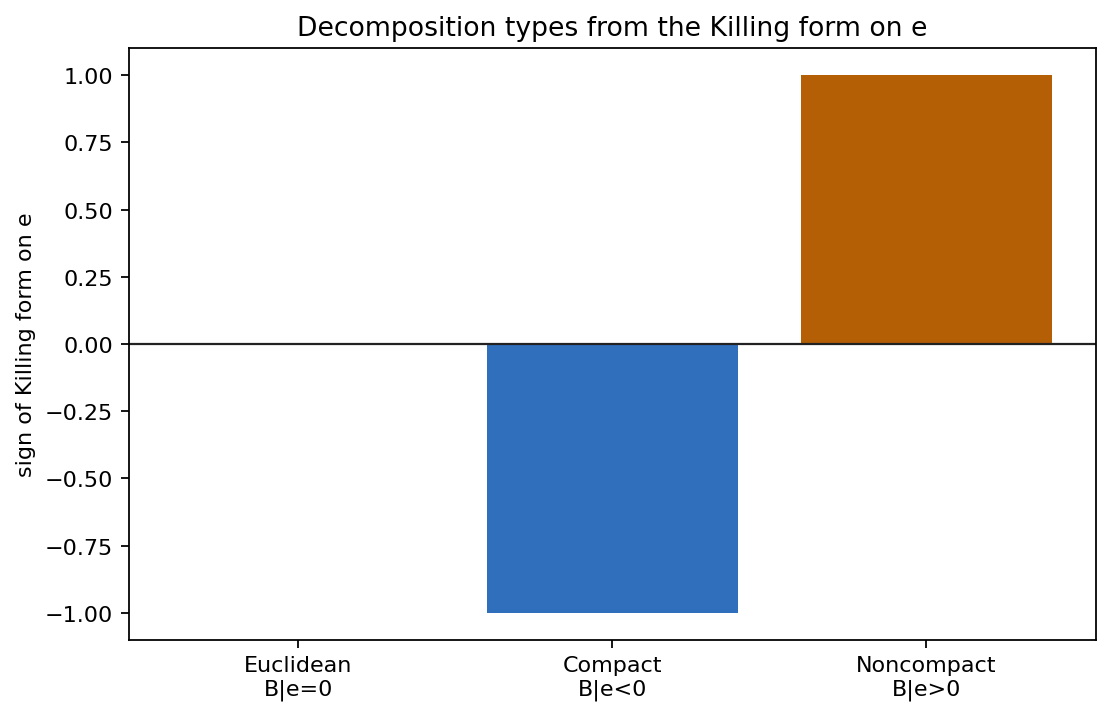

In [3]:
# Compact model: so(3)=u+e, with u=span(Az), e=span(Ax,Ay).
Ax = sp.Matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
Ay = sp.Matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
Az = sp.Matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

# Noncompact model: sl(2,R)=u+e, with u=span(K), e=span(P1,P2).
K = sp.Matrix([[0, 1], [-1, 0]])
P1 = sp.Matrix([[1, 0], [0, -1]])
P2 = sp.Matrix([[0, 1], [1, 0]])

def B_so3(A, B):
    return sp.trace(A * B)

def B_sl2(A, B):
    return 4 * sp.trace(A * B)

# Euclidean type model se(2): basis R,T1,T2 with [T1,T2]=0.
euclidean_brackets = {
    "[T1,T2]": (0, 0, 0),
    "[R,T1]": (0, 0, 1),
    "[R,T2]": (0, -1, 0),
}

type_rows = [
    {
        "type": "Euclidean",
        "model": "se(2)/so(2)",
        "B_on_e_signature": "zero/degenerate",
        "[e,e]": "0",
        "curvature_sign": "0",
        "check": euclidean_brackets["[T1,T2]"] == (0, 0, 0),
    },
    {
        "type": "Compact",
        "model": "so(3)/so(2)",
        "B_on_e_signature": str((B_so3(Ax, Ax), B_so3(Ay, Ay))),
        "[e,e]": "span(Az)",
        "curvature_sign": ">= 0",
        "check": bool(comm(Ax, Ay) == Az and B_so3(Ax, Ax) < 0 and B_so3(Ay, Ay) < 0),
    },
    {
        "type": "Noncompact",
        "model": "sl(2,R)/so(2)",
        "B_on_e_signature": str((B_sl2(P1, P1), B_sl2(P2, P2))),
        "[e,e]": "span(K)",
        "curvature_sign": "<= 0",
        "check": bool(matrix_is_multiple(comm(P1, P2), K) and B_sl2(P1, P1) > 0 and B_sl2(P2, P2) > 0),
    },
]
type_table = record(save_csv(type_rows, TABLES / "decomposition_type_killing_signs.csv"))

fig, ax = plt.subplots(figsize=(7.8, 4.8))
bars = [0, -1, 1]
labels = ["Euclidean\nB|e=0", "Compact\nB|e<0", "Noncompact\nB|e>0"]
colors = ["#6f7d8c", "#2f6fbb", "#b45f06"]
ax.bar(labels, bars, color=colors)
ax.axhline(0, color="#222222", linewidth=1)
ax.set_ylabel("sign of Killing form on e")
ax.set_title("Decomposition types from the Killing form on e")
type_fig = record(save_matplotlib(fig, FIGURES / "decomposition_type_killing_signs.png"))
plt.close(fig)

type_checks = {
    "euclidean_e_is_abelian": bool(type_rows[0]["check"]),
    "compact_e_bracket_spans_u_and_B_negative": bool(type_rows[1]["check"]),
    "noncompact_e_bracket_spans_u_and_B_positive": bool(type_rows[2]["check"]),
}
type_report = record(save_json(type_checks, CHECKS / "decomposition_type_killing_sign_checks.json"))
chapter_checks["three_type_models_valid"] = all(type_checks.values())
print(json.dumps({"figure": rel(type_fig), "table": rel(type_table), "checks": rel(type_report)}, indent=2))
display_artifact(type_fig)


## 2. The Ideal Decomposition `l0 + l- + l+`

The proof of Theorem 1.1 constructs eigenspaces of an endomorphism `b` defined by the Killing form and a positive invariant form. Those eigenspaces create ideals `l0`, `l-`, and `l+`. The graph is a compact reading map: it separates the proof ingredients from the geometric conclusions.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/orthogonal_symmetric_lie_algebra_factor_graph.png",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/orthogonal_symmetric_lie_algebra_factor_checks.json"
}


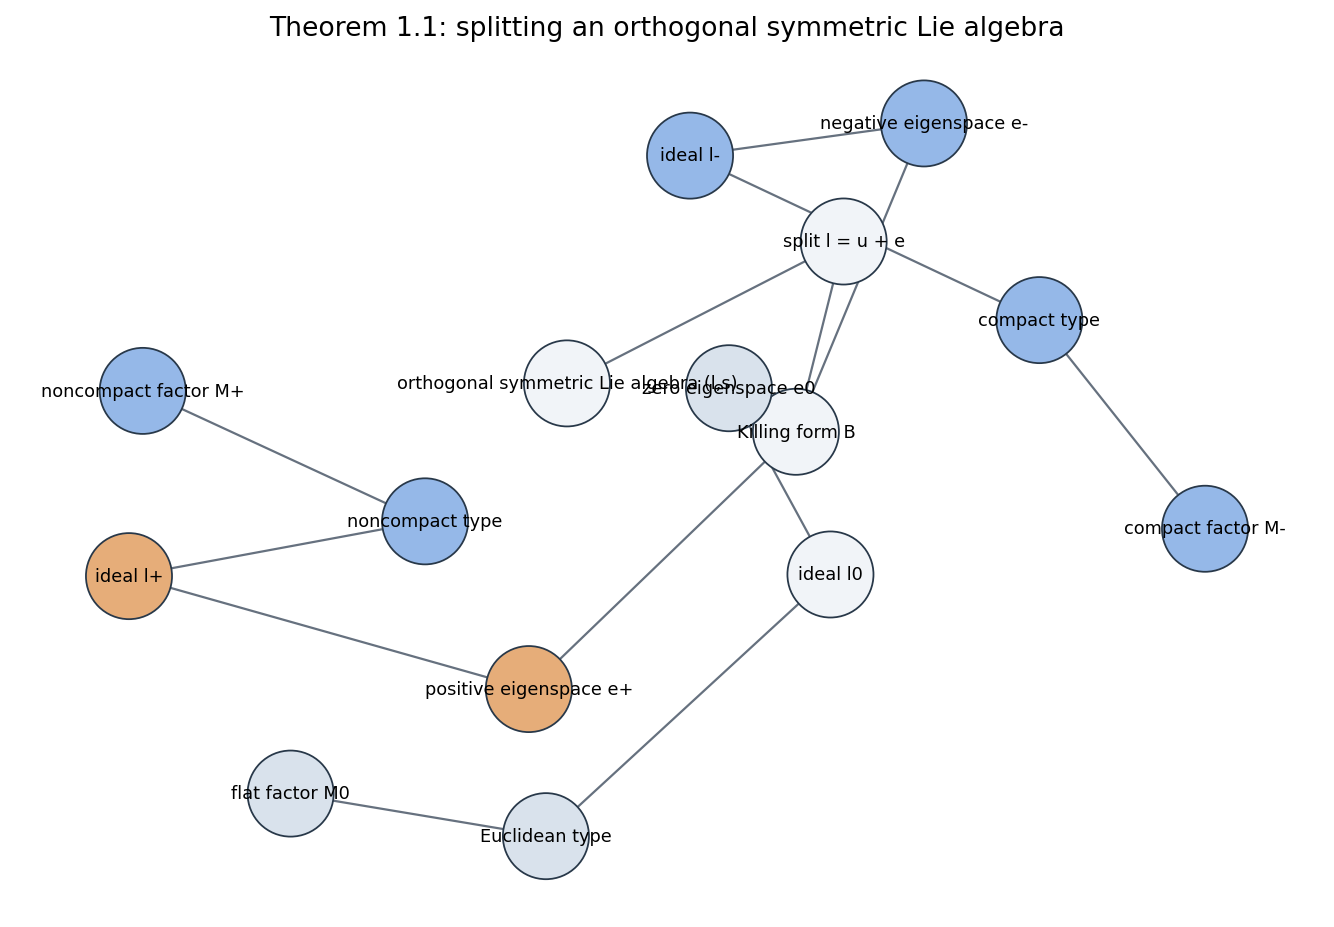

In [4]:
factor_edges = [
    ("orthogonal symmetric Lie algebra (l,s)", "split l = u + e"),
    ("split l = u + e", "Killing form B"),
    ("Killing form B", "zero eigenspace e0"),
    ("Killing form B", "negative eigenspace e-"),
    ("Killing form B", "positive eigenspace e+"),
    ("zero eigenspace e0", "ideal l0"),
    ("negative eigenspace e-", "ideal l-"),
    ("positive eigenspace e+", "ideal l+"),
    ("ideal l0", "Euclidean type"),
    ("ideal l-", "compact type"),
    ("ideal l+", "noncompact type"),
    ("Euclidean type", "flat factor M0"),
    ("compact type", "compact factor M-"),
    ("noncompact type", "noncompact factor M+"),
]
FG = nx.DiGraph()
FG.add_edges_from(factor_edges)
pos = nx.spring_layout(FG, seed=11, k=0.82)
fig, ax = plt.subplots(figsize=(10.5, 7.0))
node_colors = []
for node in FG.nodes:
    if "Euclidean" in node or "M0" in node or "e0" in node:
        node_colors.append("#d9e2ec")
    elif "compact" in node or "e-" in node or "l-" in node:
        node_colors.append("#95b8e8")
    elif "noncompact" in node or "e+" in node or "l+" in node:
        node_colors.append("#e6ad79")
    else:
        node_colors.append("#f1f4f8")
nx.draw_networkx_edges(FG, pos, ax=ax, arrowstyle="-|>", arrowsize=12, edge_color="#66717f")
nx.draw_networkx_nodes(FG, pos, ax=ax, node_color=node_colors, edgecolors="#283849", node_size=1500, linewidths=0.8)
nx.draw_networkx_labels(FG, pos, ax=ax, font_size=8)
ax.set_title("Theorem 1.1: splitting an orthogonal symmetric Lie algebra")
ax.axis("off")
factor_graph_fig = record(save_matplotlib(fig, FIGURES / "orthogonal_symmetric_lie_algebra_factor_graph.png"))
plt.close(fig)

factor_checks = {
    "path_to_euclidean_factor": nx.has_path(FG, "orthogonal symmetric Lie algebra (l,s)", "flat factor M0"),
    "path_to_compact_factor": nx.has_path(FG, "orthogonal symmetric Lie algebra (l,s)", "compact factor M-"),
    "path_to_noncompact_factor": nx.has_path(FG, "orthogonal symmetric Lie algebra (l,s)", "noncompact factor M+"),
    "factor_count": 3,
}
factor_report = record(save_json(factor_checks, CHECKS / "orthogonal_symmetric_lie_algebra_factor_checks.json"))
chapter_checks["factor_graph_has_all_three_types"] = all(factor_checks[k] for k in ["path_to_euclidean_factor", "path_to_compact_factor", "path_to_noncompact_factor"])
print(json.dumps({"figure": rel(factor_graph_fig), "checks": rel(factor_report)}, indent=2))
display_artifact(factor_graph_fig)


## 3. Duality: Keep `u`, Replace `e` by `i e`

The dual pair is `l* = u + i e` inside the complexification. For the rank-one compact model, replacing `Ax` and `Ay` by `i Ax` and `i Ay` flips the sign of their bracket. This algebraic sign flip is the same compact/noncompact contrast behind the formal relation between spherical and hyperbolic trigonometry.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/compact_noncompact_duality.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/compact_noncompact_duality_table.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/compact_noncompact_duality_checks.json"
}


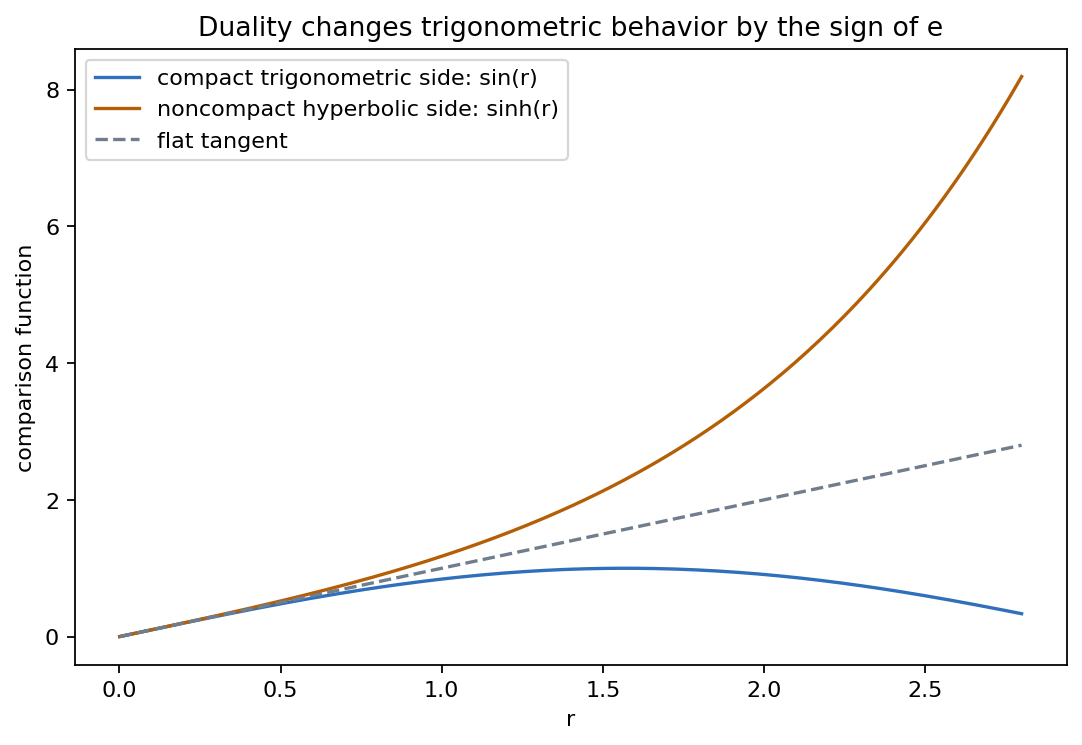

In [5]:
I = sp.I
dual_bracket = comm(I * Ax, I * Ay)
duality_rows = [
    {"side": "compact", "space": "SO(3)/SO(2)", "p_basis": "Ax, Ay", "sample_bracket": "[Ax,Ay] = Az", "curvature": "positive"},
    {"side": "dual noncompact", "space": "SL(2,R)/SO(2)", "p_basis": "i Ax, i Ay", "sample_bracket": "[iAx,iAy] = -Az", "curvature": "negative"},
]
duality_table = record(save_csv(duality_rows, TABLES / "compact_noncompact_duality_table.csv"))

r = np.linspace(0.001, 2.8, 220)
fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(r, np.sin(r), color="#2f6fbb", label="compact trigonometric side: sin(r)")
ax.plot(r, np.sinh(r), color="#b45f06", label="noncompact hyperbolic side: sinh(r)")
ax.plot(r, r, color="#6f7d8c", linestyle="--", label="flat tangent")
ax.set_title("Duality changes trigonometric behavior by the sign of e")
ax.set_xlabel("r")
ax.set_ylabel("comparison function")
ax.legend()
duality_fig = record(save_matplotlib(fig, FIGURES / "compact_noncompact_duality.png"))
plt.close(fig)

duality_checks = {
    "dual_bracket_flips_sign": bool(dual_bracket == -Az),
    "compact_sin_below_linear_near_1": bool(np.sin(1.0) < 1.0),
    "noncompact_sinh_above_linear_near_1": bool(np.sinh(1.0) > 1.0),
}
duality_report = record(save_json(duality_checks, CHECKS / "compact_noncompact_duality_checks.json"))
chapter_checks["duality_flips_bracket_sign"] = duality_checks["dual_bracket_flips_sign"]
chapter_checks["duality_matches_sin_sinh_behavior"] = duality_checks["compact_sin_below_linear_near_1"] and duality_checks["noncompact_sinh_above_linear_near_1"]
print(json.dumps({"figure": rel(duality_fig), "table": rel(duality_table), "checks": rel(duality_report)}, indent=2))
display_artifact(duality_fig)


## 4. Sectional Curvature Reads the Type

Section 3 proves that compact type has nonnegative sectional curvature, noncompact type has nonpositive sectional curvature, and Euclidean type has zero curvature. In the semisimple cases the sign comes from `B([X,Y],[X,Y])`, with the compact metric using `-B` and the noncompact metric using `B` on `e`.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/sectional_curvature_type_signs.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/sectional_curvature_type_signs.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/sectional_curvature_type_sign_checks.json"
}


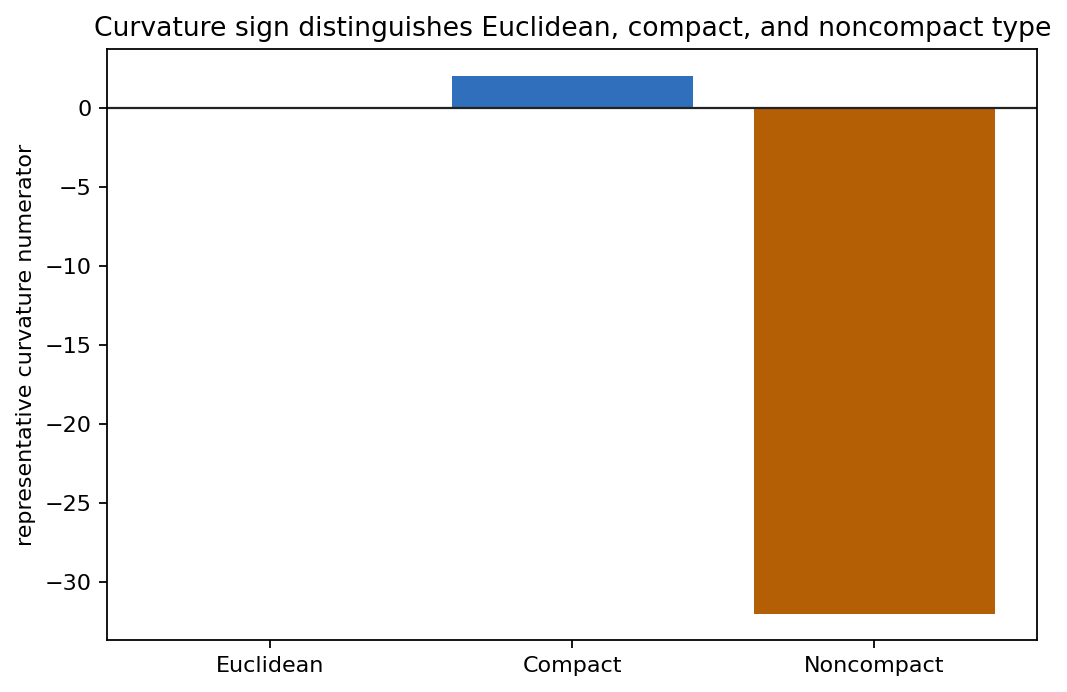

In [6]:
compact_bracket = comm(Ax, Ay)
noncompact_bracket = comm(P1, P2)
compact_curv_value = -B_so3(compact_bracket, compact_bracket)
noncompact_curv_value = B_sl2(noncompact_bracket, noncompact_bracket)
euclidean_curv_value = 0

curv_rows = [
    {"type": "Euclidean", "sample_section": "span(T1,T2)", "curvature_expression": "0", "value": float(euclidean_curv_value), "expected_sign": "zero"},
    {"type": "Compact", "sample_section": "span(Ax,Ay)", "curvature_expression": "-B([Ax,Ay],[Ax,Ay])", "value": float(compact_curv_value), "expected_sign": "positive"},
    {"type": "Noncompact", "sample_section": "span(P1,P2)", "curvature_expression": "B([P1,P2],[P1,P2])", "value": float(noncompact_curv_value), "expected_sign": "negative"},
]
curv_table = record(save_csv(curv_rows, TABLES / "sectional_curvature_type_signs.csv"))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar([row["type"] for row in curv_rows], [row["value"] for row in curv_rows], color=["#6f7d8c", "#2f6fbb", "#b45f06"])
ax.axhline(0, color="#222222", linewidth=1)
ax.set_ylabel("representative curvature numerator")
ax.set_title("Curvature sign distinguishes Euclidean, compact, and noncompact type")
curv_fig = record(save_matplotlib(fig, FIGURES / "sectional_curvature_type_signs.png"))
plt.close(fig)

curv_checks = {
    "euclidean_zero": euclidean_curv_value == 0,
    "compact_positive": bool(compact_curv_value > 0),
    "noncompact_negative": bool(noncompact_curv_value < 0),
    "zero_curvature_when_section_abelian": euclidean_brackets["[T1,T2]"] == (0, 0, 0),
}
curv_report = record(save_json(curv_checks, CHECKS / "sectional_curvature_type_sign_checks.json"))
chapter_checks["curvature_sign_theorem_models"] = all(curv_checks.values())
print(json.dumps({"figure": rel(curv_fig), "table": rel(curv_table), "checks": rel(curv_report)}, indent=2))
display_artifact(curv_fig)


## 5. Semisimple Isometry Groups and Curvature Span

For semisimple symmetric pairs acting effectively, Helgason identifies the identity component of the full isometry group and shows that the isotropy algebra is generated by curvature endomorphisms. Algebraically, the visible test is `[e,e] = u`. The Euclidean model fails this semisimple test exactly because `[e,e]` vanishes.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/curvature_span_isotropy.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/curvature_span_isotropy_checks.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/curvature_span_isotropy_checks.json"
}


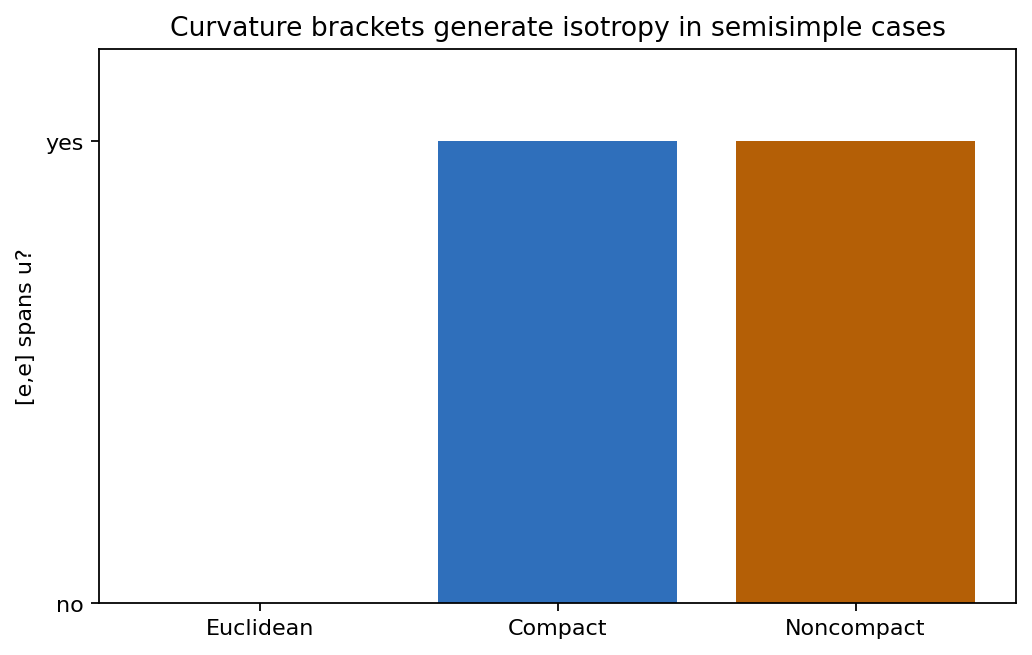

In [7]:
span_rows = [
    {"model": "Euclidean se(2)/so(2)", "u_generator": "R", "sample_[e,e]": "[T1,T2]=0", "spans_u": False, "semisimple": False},
    {"model": "Compact so(3)/so(2)", "u_generator": "Az", "sample_[e,e]": "[Ax,Ay]=Az", "spans_u": bool(comm(Ax, Ay) == Az), "semisimple": True},
    {"model": "Noncompact sl(2,R)/so(2)", "u_generator": "K", "sample_[e,e]": "[P1,P2]=2K", "spans_u": matrix_is_multiple(comm(P1, P2), K), "semisimple": True},
]
span_table = record(save_csv(span_rows, TABLES / "curvature_span_isotropy_checks.csv"))

fig, ax = plt.subplots(figsize=(7.4, 4.5))
labels = ["Euclidean", "Compact", "Noncompact"]
values = [0 if not row["spans_u"] else 1 for row in span_rows]
ax.bar(labels, values, color=["#6f7d8c", "#2f6fbb", "#b45f06"])
ax.set_ylim(0, 1.2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["no", "yes"])
ax.set_ylabel("[e,e] spans u?")
ax.set_title("Curvature brackets generate isotropy in semisimple cases")
span_fig = record(save_matplotlib(fig, FIGURES / "curvature_span_isotropy.png"))
plt.close(fig)

span_checks = {
    "compact_curvature_span_isotropy": span_rows[1]["spans_u"],
    "noncompact_curvature_span_isotropy": span_rows[2]["spans_u"],
    "euclidean_not_semisimple_and_not_spanned": not span_rows[0]["spans_u"] and not span_rows[0]["semisimple"],
}
span_report = record(save_json(span_checks, CHECKS / "curvature_span_isotropy_checks.json"))
chapter_checks["curvature_spans_isotropy_for_semisimple_models"] = all(span_checks.values())
print(json.dumps({"figure": rel(span_fig), "table": rel(span_table), "checks": rel(span_report)}, indent=2))
display_artifact(span_fig)


## 6. Product Decomposition of Simply Connected Symmetric Spaces

The algebra decomposition becomes a geometric product: a simply connected globally symmetric space splits as a Euclidean factor, a compact-type factor, and a noncompact-type factor. This is not just a classification slogan; it predicts curvature signs and rank contributions factor by factor.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/product_decomposition_of_symmetric_spaces.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/product_decomposition_factors.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/product_decomposition_checks.json"
}


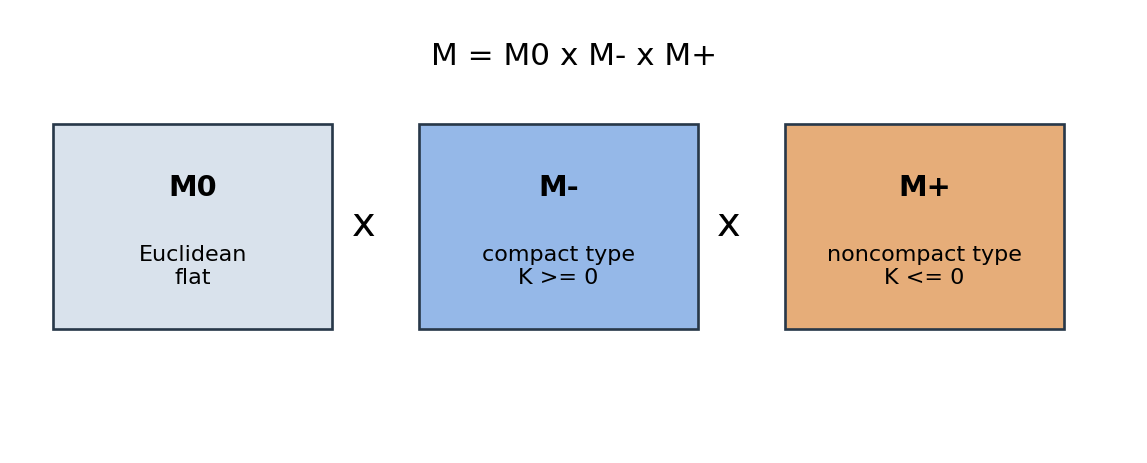

In [8]:
product_rows = [
    {"factor": "M0", "algebra_ideal": "l0", "type": "Euclidean", "curvature": "0", "rank_contribution": "dimension of flat Euclidean part"},
    {"factor": "M-", "algebra_ideal": "l-", "type": "compact", "curvature": ">= 0", "rank_contribution": "maximal abelian subspace in e-"},
    {"factor": "M+", "algebra_ideal": "l+", "type": "noncompact", "curvature": "<= 0", "rank_contribution": "maximal abelian subspace in e+"},
]
product_table = record(save_csv(product_rows, TABLES / "product_decomposition_factors.csv"))

fig, ax = plt.subplots(figsize=(9.0, 3.5))
ax.set_xlim(0, 9)
ax.set_ylim(0, 2.2)
ax.axis("off")
blocks = [
    (0.3, "M0", "Euclidean\nflat", "#d9e2ec"),
    (3.25, "M-", "compact type\nK >= 0", "#95b8e8"),
    (6.2, "M+", "noncompact type\nK <= 0", "#e6ad79"),
]
for x0, title, body, color in blocks:
    ax.add_patch(Rectangle((x0, 0.6), 2.25, 1.05, facecolor=color, edgecolor="#283849", linewidth=1.2))
    ax.text(x0 + 1.125, 1.32, title, ha="center", va="center", fontsize=13, weight="bold")
    ax.text(x0 + 1.125, 0.92, body, ha="center", va="center", fontsize=10)
ax.text(4.5, 1.95, "M = M0 x M- x M+", ha="center", fontsize=14)
ax.text(2.8, 1.08, "x", fontsize=18, ha="center")
ax.text(5.75, 1.08, "x", fontsize=18, ha="center")
product_fig = record(save_matplotlib(fig, FIGURES / "product_decomposition_of_symmetric_spaces.png"))
plt.close(fig)

product_checks = {
    "three_product_factors_recorded": len(product_rows) == 3,
    "contains_euclidean_compact_noncompact": {row["type"] for row in product_rows} == {"Euclidean", "compact", "noncompact"},
    "curvature_signs_recorded": all(row["curvature"] for row in product_rows),
}
product_report = record(save_json(product_checks, CHECKS / "product_decomposition_checks.json"))
chapter_checks["product_decomposition_has_three_factors"] = all(product_checks.values())
print(json.dumps({"figure": rel(product_fig), "table": rel(product_table), "checks": rel(product_report)}, indent=2))
display_artifact(product_fig)


## 7. Rank as the Dimension of a Maximal Flat

A flat totally geodesic submanifold corresponds to an abelian Lie triple system inside `e`. In compact or noncompact type, flat means abelian. Rank is the maximum dimension of such a subspace. A single rank-one factor has rank `1`; a product of two rank-one factors has a two-dimensional maximal flat because vectors from different factors commute.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/rank_maximal_flat_models.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/rank_maximal_flat_models.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/rank_maximal_flat_checks.json"
}


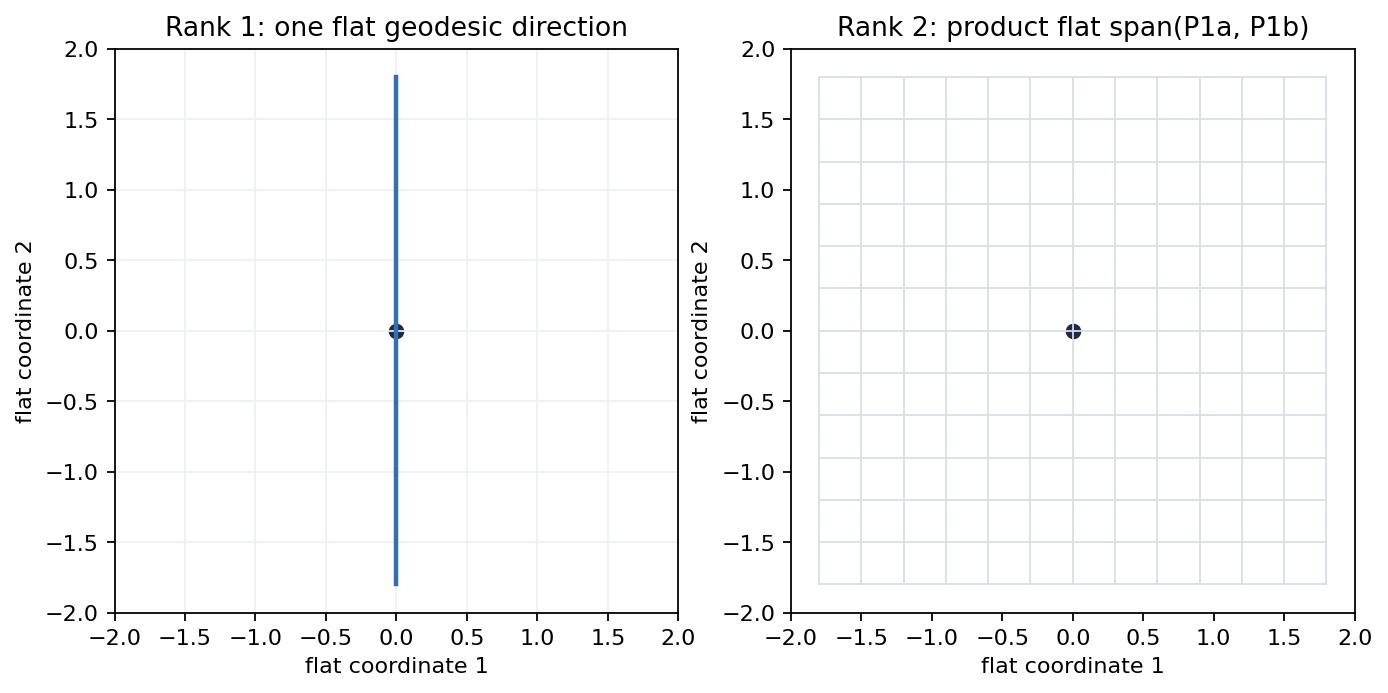

In [9]:
rank_rows = [
    {"space": "S2 or H2 rank-one model", "maximal_abelian_subspace": "span(one p direction)", "rank": 1, "commutator_check": "one-dimensional subspace commutes"},
    {"space": "H2 x H2 product model", "maximal_abelian_subspace": "span(P1 in factor 1, P1 in factor 2)", "rank": 2, "commutator_check": "cross-factor brackets vanish"},
]
rank_table = record(save_csv(rank_rows, TABLES / "rank_maximal_flat_models.csv"))

def block2(A, which):
    Z = sp.zeros(4)
    if which == 0:
        Z[:2, :2] = A
    else:
        Z[2:4, 2:4] = A
    return Z

P1_a = block2(P1, 0)
P1_b = block2(P1, 1)
P2_a = block2(P2, 0)
rank_comm_cross = comm(P1_a, P1_b)
rank_comm_same_factor = comm(P1_a, P2_a)

grid = np.linspace(-1.8, 1.8, 13)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
axes[0].plot(np.zeros_like(grid), grid, color="#2f6fbb", linewidth=2)
axes[0].scatter([0], [0], color="#1f2a44")
axes[0].set_title("Rank 1: one flat geodesic direction")
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)
axes[0].set_aspect("equal")
axes[0].grid(True, color="#edf1f5")
for x in grid:
    axes[1].plot([x, x], [grid[0], grid[-1]], color="#d7dee7", linewidth=0.8)
    axes[1].plot([grid[0], grid[-1]], [x, x], color="#d7dee7", linewidth=0.8)
axes[1].scatter([0], [0], color="#1f2a44")
axes[1].set_title("Rank 2: product flat span(P1a, P1b)")
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)
axes[1].set_aspect("equal")
for ax in axes:
    ax.set_xlabel("flat coordinate 1")
    ax.set_ylabel("flat coordinate 2")
rank_fig = record(save_matplotlib(fig, FIGURES / "rank_maximal_flat_models.png"))
plt.close(fig)

rank_checks = {
    "cross_factor_commutator_zero": bool(rank_comm_cross == sp.zeros(4)),
    "same_factor_p_directions_do_not_commute": bool(rank_comm_same_factor != sp.zeros(4)),
    "rank_adds_for_product_example": rank_rows[0]["rank"] + rank_rows[0]["rank"] == rank_rows[1]["rank"],
}
rank_report = record(save_json(rank_checks, CHECKS / "rank_maximal_flat_checks.json"))
chapter_checks["rank_flat_checks_hold"] = all(rank_checks.values())
print(json.dumps({"figure": rel(rank_fig), "table": rel(rank_table), "checks": rel(rank_report)}, indent=2))
display_artifact(rank_fig)


## 8. `KAK` and a Rank-Two Chamber in `SL(3,R)/SO(3)`

Theorem 6.7 says that, in the compact and noncompact semisimple settings, every group element can be written as `K A K`, where `A` comes from a maximal abelian subspace. In the tangent model for `SL(3,R)/SO(3)`, `p` is the space of real symmetric trace-free matrices. Orthogonal conjugation diagonalizes each sample into the rank-two flat of diagonal trace-free matrices; sorting the eigenvalues puts the result into a chamber.


{
  "figure": "artifacts/chapter-05-decomposition-of-symmetric-spaces/figures/sl3_so3_rank_two_chamber.png",
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/sl3_so3_rank_two_chamber.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/sl3_so3_rank_two_chamber_checks.json"
}


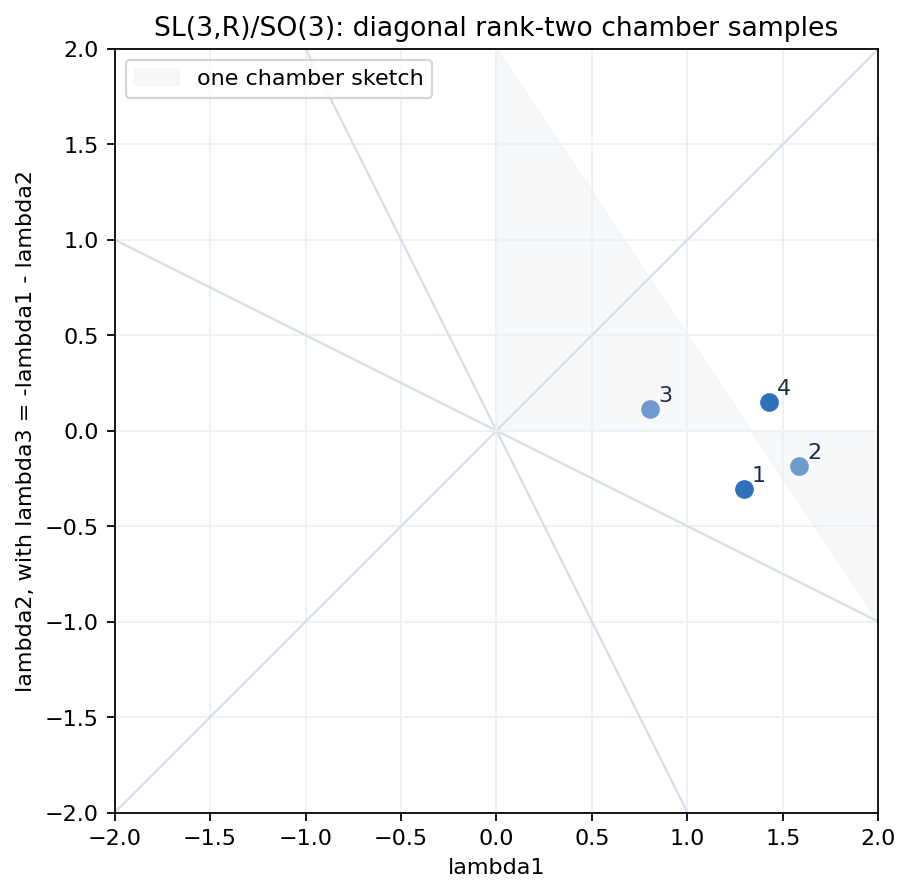

In [10]:
samples = [
    np.array([[1.2, 0.4, -0.2], [0.4, -0.5, 0.3], [-0.2, 0.3, -0.7]]),
    np.array([[0.1, -0.8, 0.2], [-0.8, 1.1, 0.5], [0.2, 0.5, -1.2]]),
    np.array([[-0.4, 0.35, 0.6], [0.35, -0.1, -0.25], [0.6, -0.25, 0.5]]),
    np.array([[1.4, -0.2, 0.15], [-0.2, -0.2, 0.7], [0.15, 0.7, -1.2]]),
]
chamber_rows = []
points = []
for idx, S in enumerate(samples, start=1):
    S = 0.5 * (S + S.T)
    S = S - np.trace(S) / 3.0 * np.eye(3)
    evals, Q = np.linalg.eigh(S)
    ordered = np.sort(evals)[::-1]
    D = np.diag(evals)
    residual = float(np.linalg.norm(Q.T @ S @ Q - D))
    frob_before = float(np.linalg.norm(S, ord="fro"))
    frob_after = float(np.linalg.norm(np.diag(ordered), ord="fro"))
    chamber_rows.append({
        "sample": idx,
        "lambda1": round(float(ordered[0]), 6),
        "lambda2": round(float(ordered[1]), 6),
        "lambda3": round(float(ordered[2]), 6),
        "sum": round(float(np.sum(ordered)), 12),
        "diagonalization_residual": residual,
        "frobenius_norm_preserved": abs(frob_before - frob_after) < 1e-10,
        "ordered_chamber": bool(ordered[0] >= ordered[1] >= ordered[2]),
    })
    points.append((ordered[0], ordered[1]))
chamber_table = record(save_csv(chamber_rows, TABLES / "sl3_so3_rank_two_chamber.csv"))

fig, ax = plt.subplots(figsize=(7.0, 6.2))
limit = 2.0
line = np.linspace(-limit, limit, 200)
ax.plot(line, line, color="#d7dee7", linewidth=1)
ax.plot(line, -2 * line, color="#d7dee7", linewidth=1)
ax.plot(-2 * line, line, color="#d7dee7", linewidth=1)
for i, (l1, l2) in enumerate(points, start=1):
    ax.scatter([l1], [l2], color="#2f6fbb", s=55)
    ax.text(l1 + 0.04, l2 + 0.04, str(i), color="#1f2a44")
ax.fill_between([0, limit], [0, 0], [limit, -0.5 * limit], color="#e8edf3", alpha=0.35, label="one chamber sketch")
ax.axhline(0, color="#edf1f5", linewidth=0.8)
ax.axvline(0, color="#edf1f5", linewidth=0.8)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal")
ax.grid(True, color="#edf1f5")
ax.set_title("SL(3,R)/SO(3): diagonal rank-two chamber samples")
ax.set_xlabel("lambda1")
ax.set_ylabel("lambda2, with lambda3 = -lambda1 - lambda2")
ax.legend(loc="upper left")
chamber_fig = record(save_matplotlib(fig, FIGURES / "sl3_so3_rank_two_chamber.png"))
plt.close(fig)

chamber_checks = {
    "all_traces_zero": all(abs(row["sum"]) < 1e-10 for row in chamber_rows),
    "all_diagonalization_residuals_small": all(row["diagonalization_residual"] < 1e-10 for row in chamber_rows),
    "all_norms_preserved": all(row["frobenius_norm_preserved"] for row in chamber_rows),
    "all_representatives_ordered": all(row["ordered_chamber"] for row in chamber_rows),
    "rank_two_flat_dimension": 2,
}
chamber_report = record(save_json(chamber_checks, CHECKS / "sl3_so3_rank_two_chamber_checks.json"))
chapter_checks["sl3_so3_rank_two_chamber_checks"] = all(value is True or value == 2 for value in chamber_checks.values())
print(json.dumps({"figure": rel(chamber_fig), "table": rel(chamber_table), "checks": rel(chamber_report)}, indent=2))
display_artifact(chamber_fig)


## Applied Lab: Switch the Type, Watch the Invariant Change

The quickest experiment is to switch among the three model types and compare four fields: whether `e` is abelian, the sign of the Killing form on `e`, the curvature sign, and the rank contribution. If the type changes but the downstream fields do not, the model is lying.


In [11]:
lab_rows = []
for row in type_rows:
    if row["type"] == "Euclidean":
        rank_hint = "translation dimension"
        abelian_e = True
    elif row["type"] == "Compact":
        rank_hint = "maximal commuting rotations in e"
        abelian_e = False
    else:
        rank_hint = "maximal commuting boosts in e"
        abelian_e = False
    lab_rows.append({
        "type": row["type"],
        "is_e_abelian_in_model": abelian_e,
        "B_on_e_signature": row["B_on_e_signature"],
        "curvature_sign": row["curvature_sign"],
        "rank_hint": rank_hint,
    })
lab_table = record(save_csv(lab_rows, TABLES / "type_switching_lab.csv"))
lab_checks = {
    "lab_has_three_types": {row["type"] for row in lab_rows} == {"Euclidean", "Compact", "Noncompact"},
    "only_euclidean_model_has_abelian_e": [row["is_e_abelian_in_model"] for row in lab_rows] == [True, False, False],
}
lab_report = record(save_json(lab_checks, CHECKS / "type_switching_lab_checks.json"))
chapter_checks["type_switching_lab_consistent"] = all(lab_checks.values())
print(json.dumps({"table": rel(lab_table), "checks": rel(lab_report)}, indent=2))
display_artifact(lab_table)


{
  "table": "artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/type_switching_lab.csv",
  "checks": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/type_switching_lab_checks.json"
}


[type_switching_lab.csv](artifacts/chapter-05-decomposition-of-symmetric-spaces/tables/type_switching_lab.csv)

## Takeaways

- The decomposition theorem is a sign decomposition for the Killing form on the `-1` eigenspace, promoted to ideals of the whole symmetric Lie algebra.
- Compact and noncompact types are dual: `e` and `i e` have the same complexification but opposite curvature behavior.
- The sectional-curvature theorem is a bracket theorem. A section is flat exactly when the relevant tangent vectors commute.
- In the semisimple effective case, curvature brackets generate the isotropy algebra and the connected isometry group is already the expected one.
- Rank measures the dimension of the largest abelian tangent subspace, equivalently the largest flat totally geodesic submanifold.


In [12]:
final_sanity = {
    "chapter": "Chapter V. Decomposition of Symmetric Spaces",
    "source_span": "printed pages 229-251, approximately PDF pages 256-278",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks,
    "coverage_note": "Sections 1-6 are represented by decomposition type models, factor graphs, duality checks, curvature sign computations, semisimple isotropy span checks, product decomposition, rank/maximal-flat models, and a KAK chamber lab.",
}
failed = [name for name, value in chapter_checks.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-05-decomposition-of-symmetric-spaces/checks/final_sanity.json",
  "boolean_checks": 11,
  "failed": []
}


`final_sanity.json`